## 1. Import libraries

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

## 2. Import data

Due to the large dataset I am going to use sample data for the following analysis and visualisations. The sample data is a small sample size randomly selected, it can be found in the script folder under "Create sample data"

In [6]:
# Import pkl data 
path = '/Users/bobbi/Careerfoundry/InstacartBasketAnalysis_01_25'

sample_data = pd.read_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'sample_data.pkl'))

In [7]:
# Check data 
sample_data.head()

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_last_order,product_id,add_to_cart_order,product_name,aisle_id,...,ords_flag,gender,state,age,date_joined,n_dependants,fam_status,income,region,max_order
0,2539329,1,1,2,8,NaN,196,1,Soda,77,...,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,South,10
2,2539329,1,1,2,8,NaN,12427,3,Original Beef Jerky,23,...,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,South,10
3,2539329,1,1,2,8,NaN,26088,4,Aged White Cheddar Popcorn,23,...,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,South,10
6,2398795,1,2,3,7,15.0,10258,2,Pistachios,117,...,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,South,10
10,2398795,1,2,3,7,15.0,13032,6,Cinnamon Toast Crunch,121,...,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,South,10


## 3. Customer profiling

#### Age group and dependants

I will create a customer segmentation based on age and number of dependants:
* Single young: age between 18 and 35, no dependants
* Young parent: age between 18 to 35 with one or more dependents
* Singe adult: age 35 to 60, no dependents
* Family Shopper: age 35+, multiple dependents
* Senior Shopper: age 60+, fewer or no dependents

In [11]:
def customer_segmentation(age, n_dependants):
    if 18 <= age <= 35 and n_dependants == 0:
        return 'Single Young'
    elif 18 <= age <= 35 and n_dependants >= 1:
        return 'Young Parent'
    elif 30 < age <= 60 and n_dependants == 0:
        return 'Single Adult'
    elif age > 35 and n_dependants >= 1:
        return 'Family Shopper'
    elif age >= 60 and n_dependants <= 1:
        return 'Senior Shopper'
    else:
        return 'Other'

In [12]:
# Apply segmentation 
sample_data['customer_segment'] = sample_data.apply(lambda row: customer_segmentation(row['age'], row['n_dependants']), axis = 1)

sample_data[['age', 'n_dependants', 'customer_segment']].head()

,age,n_dependants,customer_segment
0,31,3,Young Parent
2,31,3,Young Parent
3,31,3,Young Parent
6,31,3,Young Parent
10,31,3,Young Parent


In [13]:
sample_data[['age', 'n_dependants', 'customer_segment']].tail()

,age,n_dependants,customer_segment
32404839,74,3,Family Shopper
32404845,74,3,Family Shopper
32404852,74,3,Family Shopper
32404854,74,3,Family Shopper
32404855,74,3,Family Shopper


In [14]:
sample_data.groupby('customer_segment')['user_id'].nunique()

customer_segment
Family Shopper    87686
Senior Shopper    13205
Single Adult      15973
Single Young      11519
Young Parent      34144
Name: user_id, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

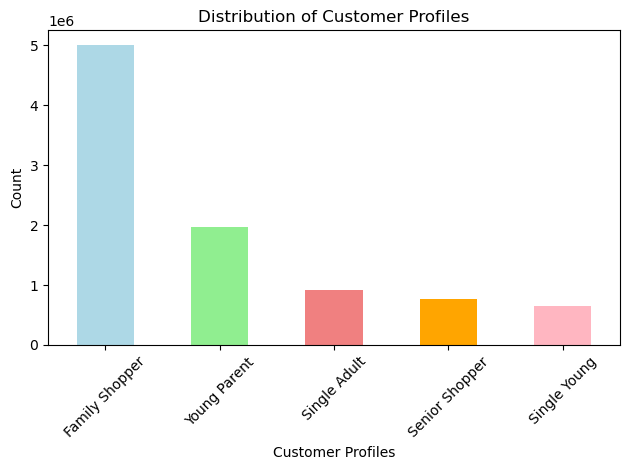

In [15]:
# Count the distribution
profile_segmentation = sample_data['customer_segment'].value_counts()

colors_segment = ['lightblue', 'lightgreen', 'lightcoral', 'orange', 'lightpink']

# Create a bar chart
profile_segmentation_bar = profile_segmentation.plot(kind='bar', color=colors_segment)
plt.xlabel('Customer Profiles')
plt.ylabel('Count')
plt.title('Distribution of Customer Profiles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

This bar chart shows the distribution of customer profiles based on a segmentation of age and number of dependents. Here is how we can describe the chart:
* The "Family Shopper" profile dominates, with a significantly higher count compared to the others. This suggests that a large portion of customers are in the 30+ age range and have multiple dependents, likely shopping for family-sized products or groceries.
* The "Senior Shopper" profile is the second most common, which could indicate a significant number of customers over 60 who may be shopping for essential or convenience items, and possibly fewer or no dependents.
* The "Young Parent" profile also shows a noticeable number of customers, indicating a group of younger individuals (aged 18-30) with children or dependents.
* The "Single Young" profile is the least common, which could reflect that fewer young, independent individuals without dependents are frequent shoppers in this dataset.
* The 'Single Adult' profile is in the middle.

The chart shows that family-oriented profiles (Family Shopper, Young Parent, Senior Shopper) are more prevalent, which aligns with the fact that families and older customers may be larger consumers, especially in categories like groceries and household goods.

There is a clear skew toward profiles with dependents, especially the Family Shopper category, suggesting that Instacart’s customer base might be heavily influenced by family needs and larger household purchases.

### Total orders per group

In [69]:
# Numbers per customer 
profile_aggregation_order = sample_data.groupby('customer_segment').agg(
    total_order=('order_id', 'sum'),
    avg_order=('order_id', 'mean'),
    median_order=('order_id', 'median'),
    std_order=('order_id', 'std'),
    min_order=('order_id', 'min'),
    max_order=('order_id', 'max'),
    order_count=('order_id', 'count'),
    avg_orders_per_customer=('order_id', 'mean')
)

profile_aggregation_order.head()

,total_order,avg_order,median_order,std_order,min_order,max_order,order_count,avg_orders_per_customer
customer_segment,,,,,,,,
Family Shopper,8542296508686,1.708921e+06,1708843.0,987188.308386,2,3421083,4998649,1.708921e+06
Senior Shopper,1299889287613,1.712654e+06,1714374.0,988747.027974,25,3421080,758991,1.712654e+06
Single Adult,1556066919657,1.712029e+06,1711781.0,985804.154176,14,3421055,908902,1.712029e+06
Single Young,1118914507059,1.710327e+06,1705955.0,986763.450408,9,3421077,654211,1.710327e+06
Young Parent,3367890545635,1.711574e+06,1711621.0,987750.628219,5,3421074,1967715,1.711574e+06


/var/folders/bs/25x482152nx68y1wp8l2g42c0000gn/T/ipykernel_12198/271679860.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  segment_boxplot = sns.boxplot(x='customer_segment', y='order_id', data=sample_data, palette=colors_segment)


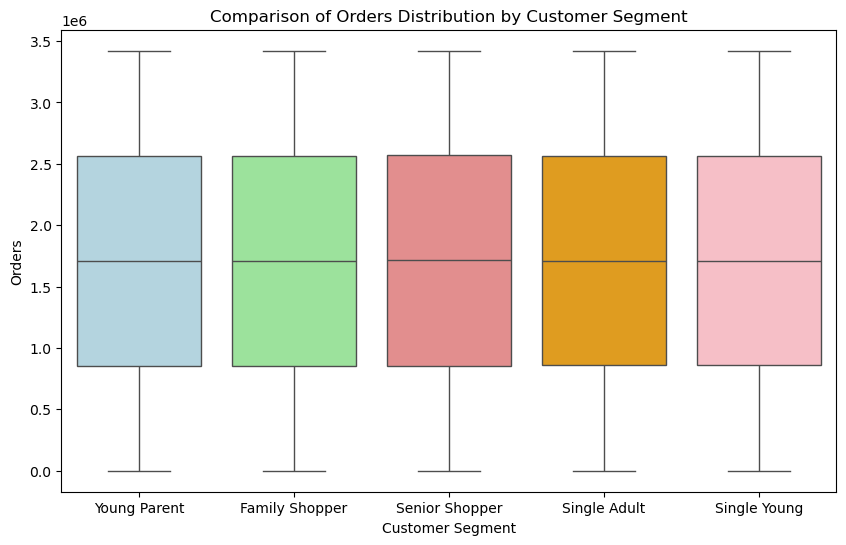

In [100]:
# Create a boxplot for spending distribution by customer segment
plt.figure(figsize=(10, 6))
segment_boxplot = sns.boxplot(x='customer_segment', y='order_id', data=sample_data, palette=colors_segment)

# Set labels and title
plt.xlabel('Customer Segment')
plt.ylabel('Orders')
plt.title('Comparison of Orders Distribution by Customer Segment')

# Show the plot
plt.show()

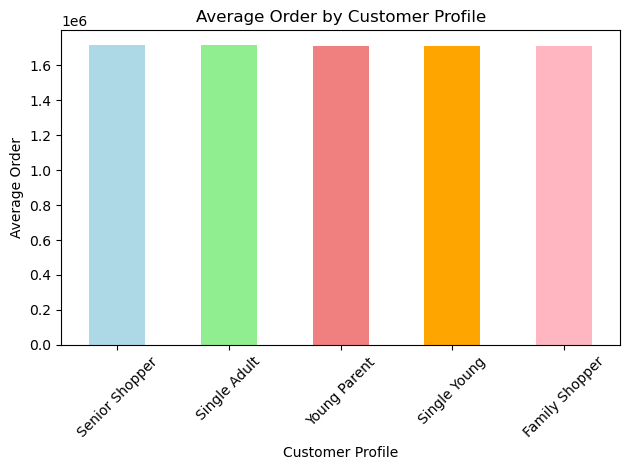

In [86]:
# Bar chart for total spending across customer profiles
profile_aggregation_sorted_order = profile_aggregation_order.sort_values(by='avg_order', ascending=False)

bar_avg_order = profile_aggregation_sorted_order['avg_order'].plot(kind='bar', color=colors_segment)
plt.title('Average Order by Customer Profile')
plt.xlabel('Customer Profile')
plt.ylabel('Average Order')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Total spending per group

In [ ]:
# Numbers per customer 
profile_aggregation = sample_data.groupby('customer_segment').agg(
    total_spending=('prices', 'sum'),
    avg_spending=('prices', 'mean'),
    median_spending=('prices', 'median'),
    std_spending=('prices', 'std'),
    min_spending=('prices', 'min'),
    max_spending=('prices', 'max'),
    order_count=('order_id', 'count'),
    avg_orders_per_customer=('order_id', 'mean')
)

profile_aggregation.head()

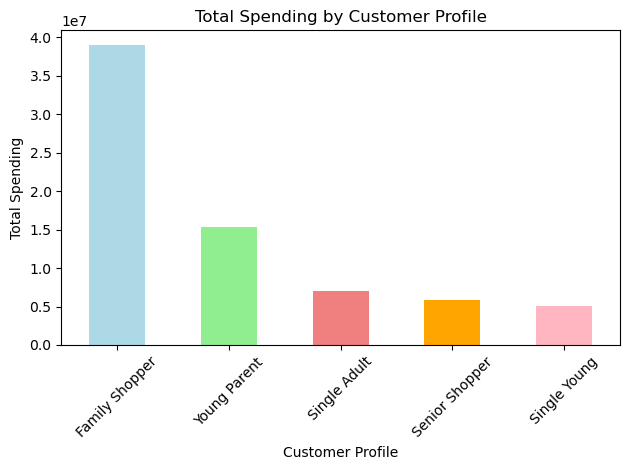

In [19]:
# Bar chart for total spending across customer profiles
profile_aggregation_sorted = profile_aggregation.sort_values(by='total_spending', ascending=False)

bar_total_spending = profile_aggregation_sorted['total_spending'].plot(kind='bar', color=colors_segment)
plt.title('Total Spending by Customer Profile')
plt.xlabel('Customer Profile')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart shows the total spending by each customer profile. This are the key takeaways:
* The "Family Shopper" segment leads by a significant margin, with total spending far exceeding the other profiles. This suggests that families or customers with dependents are responsible for a substantial portion of overall spending. This indicates that marketing and product offerings targeting this group, such as bulk purchases, groceries, and household essentials, could be highly effective.
* The "Young Parent" profile also shows notable total spending, but significantly less than "Family Shopper".
* The "Single Adult" profile contributes less to total spending than Young Parent but is still noteworthy. This segment (30-60), even-though they don't have any dependants, usually has a higher spending power.
* The "Senior Shopper" profile shows a moderate amount of total spending, which is expected as customers in the 60+ age range might spend less or in convenient products.
* The "Single Young" profile shows the least amount of total spending, this group usually has a lower income and therefore a lower spending power.

The Family Shopper profile dominates spending, highlighting a significant opportunity for businesses to focus on products that serve families. However, Young Parents, Single Adults, and Senior Shoppers still present substantial opportunities for growth through tailored marketing and product offerings.

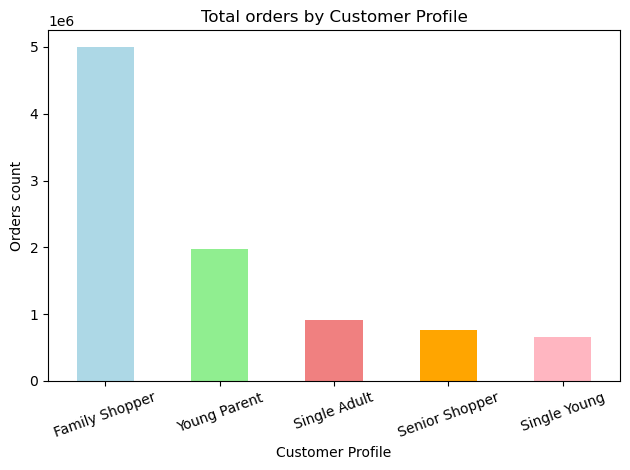

In [21]:
profile_order_sorted = profile_aggregation.sort_values(by='order_count', ascending=False)

bar_total_orders = profile_order_sorted['order_count'].plot(kind='bar', color=colors_segment)
plt.title('Total orders by Customer Profile')
plt.xlabel('Customer Profile')
plt.ylabel('Orders count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

This bar chart shows the total number of orders made by each customer profile. It shows the "Family Shopper" group is the clear market leader in both spending and order frequency. This means that a large portion of Instacart’s business is driven by families, indicating that family-sized product offerings (e.g., bulk purchases, household goods, groceries) should be a central focus in marketing campaigns.

Young Parents also represent an important group with regular orders, and targeting them with time-saving or family-oriented solutions can further boost engagement.

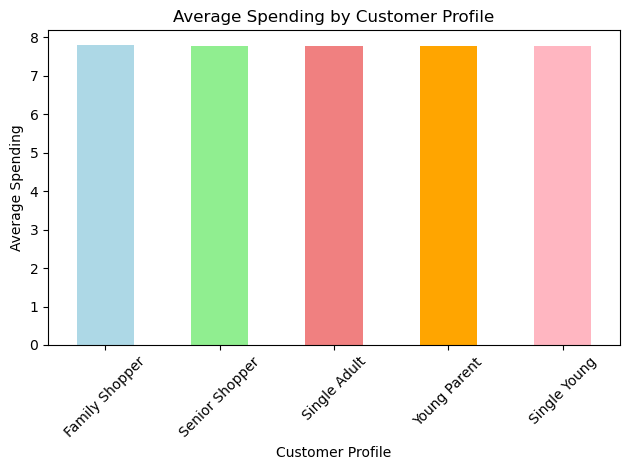

In [88]:
# Bar chart for average spending across customer profiles
profile_aggregation_sorted = profile_aggregation.sort_values(by='avg_spending', ascending=False)

bar_avg_spending = profile_aggregation_sorted['avg_spending'].plot(kind='bar', color=colors_segment)
plt.title('Average Spending by Customer Profile')
plt.xlabel('Customer Profile')
plt.ylabel('Average Spending')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

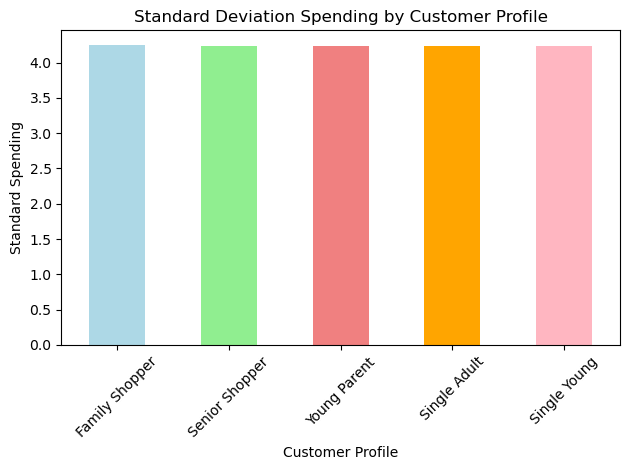

In [90]:
# Bar chart for standard deviation spending across customer profiles
profile_aggregation_sorted = profile_aggregation.sort_values(by='std_spending', ascending=False)

bar_std_spending = profile_aggregation_sorted['std_spending'].plot(kind='bar', color=colors_segment)
plt.title('Standard Deviation Spending by Customer Profile')
plt.xlabel('Customer Profile')
plt.ylabel('Standard Spending')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The two visualizations, average spending and standard deviation spending, provide insights into the spending behaviors of different customer profiles.

Average Spending:

* The average spending by customer profile is relatively similar across all groups, with Family Shoppers, Senior Shoppers, Single Adults, Young Parents, and Single Young shoppers spending around the same amount (around 7.7 for all segments).
* This suggests that while the total spending differs between profiles (with Family Shoppers being the largest spenders), the average spending per transaction is consistent across these groups.

Standard Deviation Spending:

* The standard deviation of spending is also comparable among all customer segments, with each profile showing similar variability in their spending (ranging from 3.7 to 4).
* This indicates that, despite differences in total spending, customers within each group demonstrate consistent shopping behaviors in terms of spending per order.
* The even spread of standard deviation across segments suggests that marketing efforts should aim to keep the spending patterns consistent, particularly for Family Shoppers, who are the largest contributors to total spending.
  
Both visualizations help highlight that while average spending varies slightly across segments, the variation in spending remains consistent, implying that consistent purchasing behaviors could be promoted for all profiles.

#### Income segmentation

I am going to define income brackets using the mean and standard deviation of the income distribution as follows:
* Low income: below the mean minus one standard deviation
* Middle income: between the mean minus one standard deviation and the mean plus one standard deviation.
* High income: above the mean plus one standard deviation

In [29]:
# Calculate mean and standard deviation of the 'income' column
mean_income = sample_data['income'].mean()
std_income = sample_data['income'].std()

# Define the thresholds
low_threshold = mean_income - std_income
high_threshold = mean_income + std_income

# Create the 'income_group' column based on these thresholds
sample_data['income_group'] = pd.cut(sample_data['income'],
                                       bins=[0, low_threshold, high_threshold, float('inf')],
                                       labels=['Low income', 'Middle income', 'High income'],
                                       right=False)

sample_data.groupby('income_group')['user_id'].nunique()

/var/folders/bs/25x482152nx68y1wp8l2g42c0000gn/T/ipykernel_12198/1287673100.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_data.groupby('income_group')['user_id'].nunique()


income_group
Low income        33606
Middle income    103619
High income       25302
Name: user_id, dtype: int64

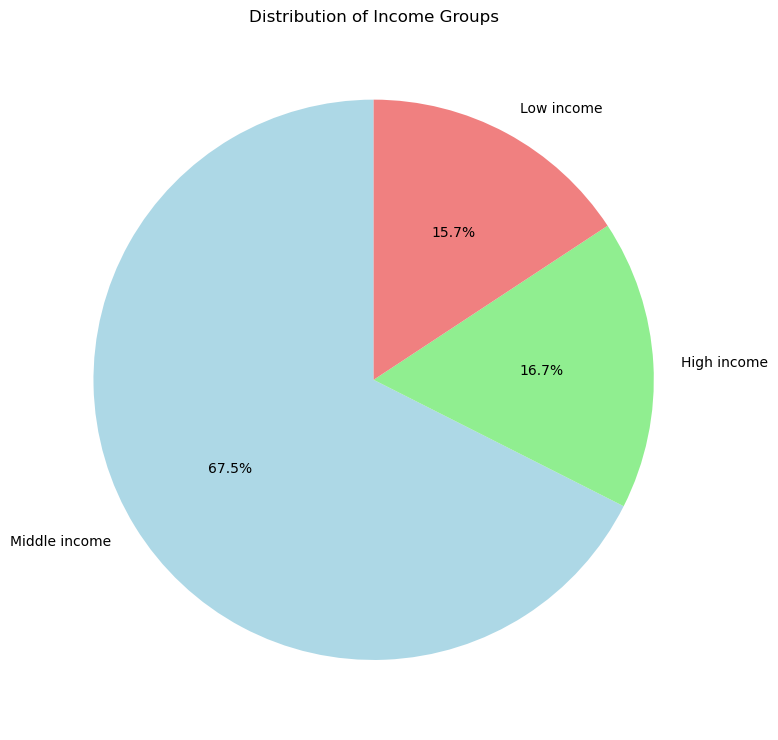

In [30]:
# Count number of customers in each group 
income_group_counts = sample_data['income_group'].value_counts()

income_colors = ['lightblue', 'lightgreen', 'lightcoral']

# Create a pie chart
plt.figure(figsize=(8, 8))
pie_income = plt.pie(income_group_counts, labels=income_group_counts.index, autopct='%1.1f%%', startangle=90, colors=income_colors)

# Save the figure
plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'pie_income.png'))

# Set the title
plt.title('Distribution of Income Groups')
plt.tight_layout()
plt.show()

In [31]:
# Create a cross tabulation between income_group and customer_segment
cross_tab = pd.crosstab(
    sample_data['income_group'],
    sample_data['customer_segment'],
    values = sample_data['order_id'],
    aggfunc='count',
    margins=True
)

cross_tab

customer_segment,Family Shopper,Senior Shopper,Single Adult,Single Young,Young Parent,All
income_group,,,,,,
Low income,587671,74072,118848,172045,508579,1461215
Middle income,3272046,491474,595921,475526,1439347,6274314
High income,1138932,193445,194133,6640,19789,1552939
All,4998649,758991,908902,654211,1967715,9288468


In [32]:
print(cross_tab.index)

Index(['Low income', 'Middle income', 'High income', 'All'], dtype='object', name='income_group')


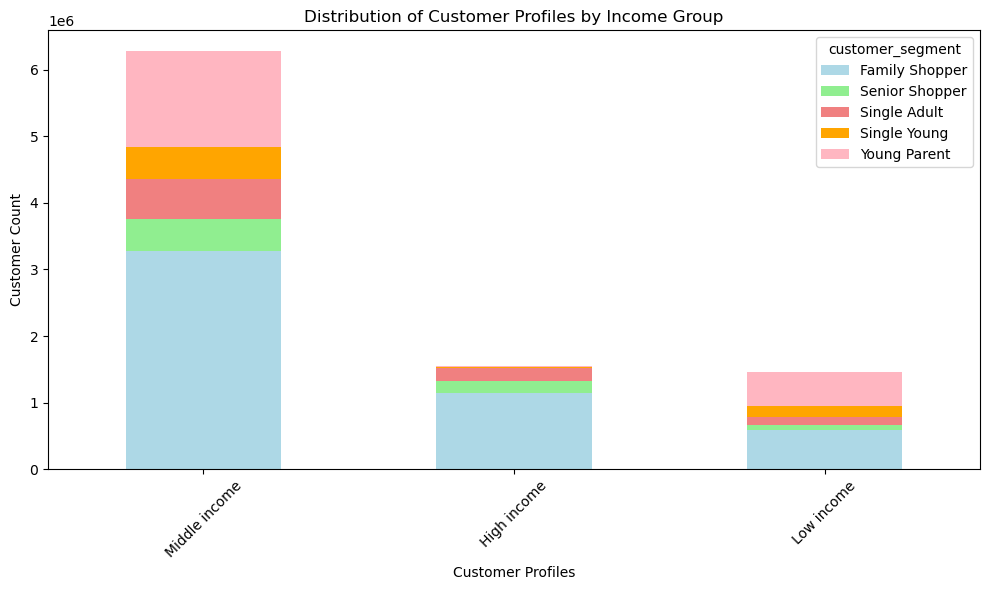

In [33]:
# Drop the 'All' column (or row) if it exists
cross_tab = cross_tab.drop(columns='All', axis=1, errors='ignore')  # Drop 'All' column if it's present
cross_tab = cross_tab.drop('All', axis=0, errors='ignore')  # Drop 'All' row if it's in the index

# Sort values based on the sum of each income group
cross_tab_sorted = cross_tab.loc[cross_tab.sum(axis=1).sort_values(ascending=False).index]

# Plot the stacked bar chart
customer_income_distribution = cross_tab_sorted.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors_segment)

# Set labels and title
plt.xlabel('Customer Profiles')
plt.ylabel('Customer Count')
plt.title('Distribution of Customer Profiles by Income Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The stacked bar chart shown represents the distribution of customer profiles across different income groups. Here's how we can interpret the chart:
* The Middle income group is by far the largest segment, both in terms of total customers and across all customer profiles.
* Family Shoppers appear to be a dominant group in all income brackets, with a particularly high concentration in the Middle income group. This was to be expected as they represent three times the amount of custumers than other segments.
* Low income has fewer customers overall, but the Family Shopper and Young Parents profiles are still prominent in this income bracket.
* There seems to be a lower proportion of Senior Shoppers and Single Young in the Low income and High income groups, with the Middle income group showing more balance across different profiles. As expected there are almost no Single Young in the High income bracket.

### Product segmentation

To create a product segmentation I need to merge the department data (department name) with the sample_data. First I will import the clean department data, then merge it with the existing data and then proceed to continue with the analysis

In [37]:
# Import clean department data
dep_data = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data', 'departments_wrangled.csv'))

dep_data.head()

,Unnamed: 0,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [38]:
dep_data = dep_data.rename(columns={'Unnamed: 0': 'department_id'})

dep_data

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [39]:
sample_data.shape

(9288468, 28)

In [40]:
# Merge data 
sample_data = sample_data.merge(dep_data, on = 'department_id')

In [41]:
sample_data.head()

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_last_order,product_id,add_to_cart_order,product_name,aisle_id,...,age,date_joined,n_dependants,fam_status,income,region,max_order,customer_segment,income_group,department
0,2539329,1,1,2,8,NaN,196,1,Soda,77,...,31,2/17/2019,3,married,40423,South,10,Young Parent,Low income,beverages
1,2539329,1,1,2,8,NaN,12427,3,Original Beef Jerky,23,...,31,2/17/2019,3,married,40423,South,10,Young Parent,Low income,snacks
2,2539329,1,1,2,8,NaN,26088,4,Aged White Cheddar Popcorn,23,...,31,2/17/2019,3,married,40423,South,10,Young Parent,Low income,snacks
3,2398795,1,2,3,7,15.0,10258,2,Pistachios,117,...,31,2/17/2019,3,married,40423,South,10,Young Parent,Low income,snacks
4,2398795,1,2,3,7,15.0,13032,6,Cinnamon Toast Crunch,121,...,31,2/17/2019,3,married,40423,South,10,Young Parent,Low income,breakfast


In [42]:
# Create product groups
sample_data.loc[sample_data['department_id'] == (1 or 3 or 4 or 9 or 10 or 12 or 13 or 14 or 15 or 16 or 19 or 20), 'product_group'] = 'Food'
sample_data.loc[sample_data['department_id'] == (5 or 7), 'product_group'] = 'Drink'
sample_data.loc[sample_data['department_id'] == (18), 'product_group'] = 'Baby care'
sample_data.loc[sample_data['department_id'] == (8), 'product_group'] = 'Pet care'
sample_data.loc[sample_data['department_id'] == (2 or 11 or 17), 'product_group'] = 'Non-consumable'

In [43]:
sample_data.groupby('product_group')['user_id'].nunique()

product_group
Baby care          21200
Drink               9380
Food              112137
Non-consumable      7109
Pet care            8236
Name: user_id, dtype: int64

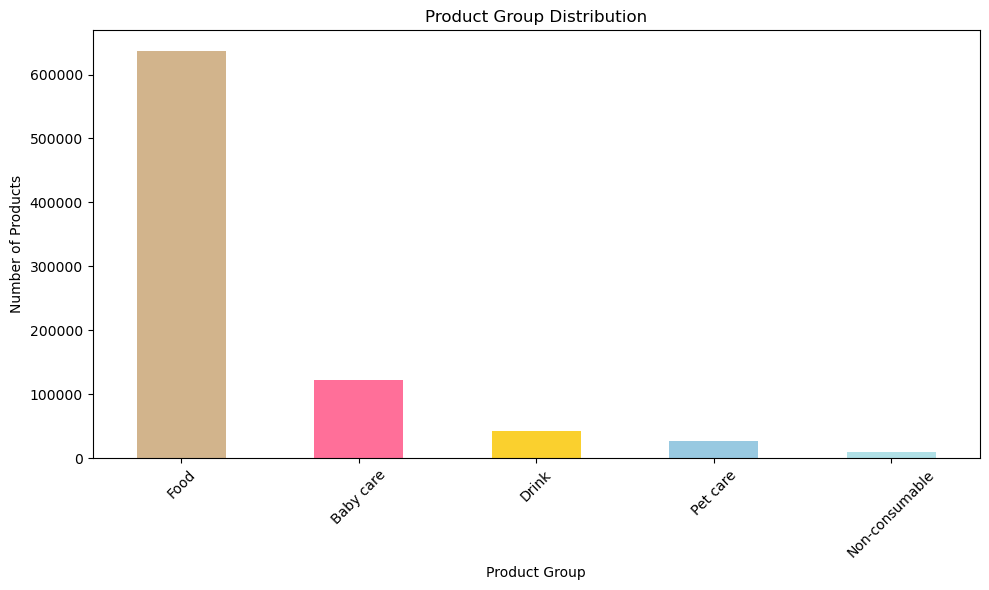

In [44]:
# Count the number of occurrences of each product group
product_group_counts = sample_data['product_group'].value_counts()

colors_product = ['#D2B48C', '#FF6F99', '#FAD02E', '#98C9E1', '#B0E0E6']

# Create a bar chart for product group distribution
product_bar = product_group_counts.plot(kind='bar', color=colors_product, figsize=(10, 6))

# Set labels and title
plt.xlabel('Product Group')
plt.ylabel('Number of Products')
plt.title('Product Group Distribution')

# Display the chart
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

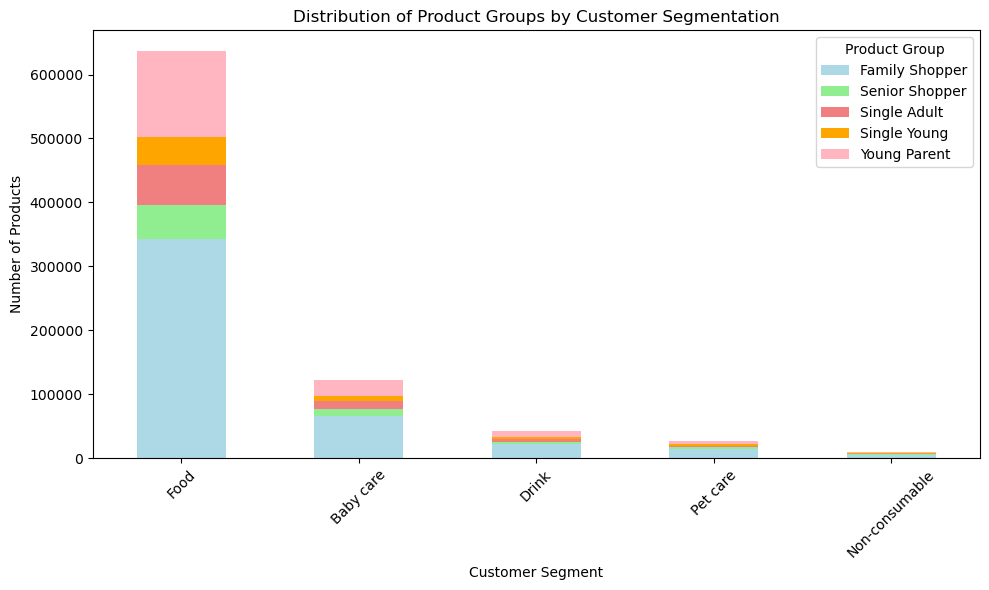

In [45]:
# Create a stacked bar chart of Product Group distribution by Customer Segmentation
product_group_by_segment = sample_data.groupby(['product_group', 'customer_segment']).size().unstack()

# Sort the product group distribution by the total number of products in each customer segment
product_group_by_segment_sorted = product_group_by_segment.sum(axis=1).sort_values(ascending=False)

# Reorder the columns according to the sorted customer segments
product_group_by_segment_sorted = product_group_by_segment.loc[product_group_by_segment_sorted.index]

# Plot the stacked bar chart
product_customer_bar = product_group_by_segment_sorted.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors_segment)

# Set labels and title
plt.xlabel('Customer Segment')
plt.ylabel('Number of Products')
plt.title('Distribution of Product Groups by Customer Segmentation')

# Display the legend and adjust the x-axis labels
plt.legend(title='Product Group')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the chart
plt.show()

This stacked bar chart shows the distribution of product groups by customer segment. Here's the main takeaways:
* Food is the largest category by far (it also has the most items available), especially for Family Shoppers.
* Other product groups have significally fewer items and are sold less. As expected Family Shoppers and Young Parents are the ones who buy most of baby care.
* Family Shopper contributes the most to the Food category, followed by smaller contributions to Baby Care and Drink.
* Single Adult and Young Parent segments also show notable participation in Food. Senior Shopper and Young Adult have smaller contributions overall.
* Food is the most popular category across all segments, while other categories like Pet Care and Non-consumable are less significant.

### Distribution through Region

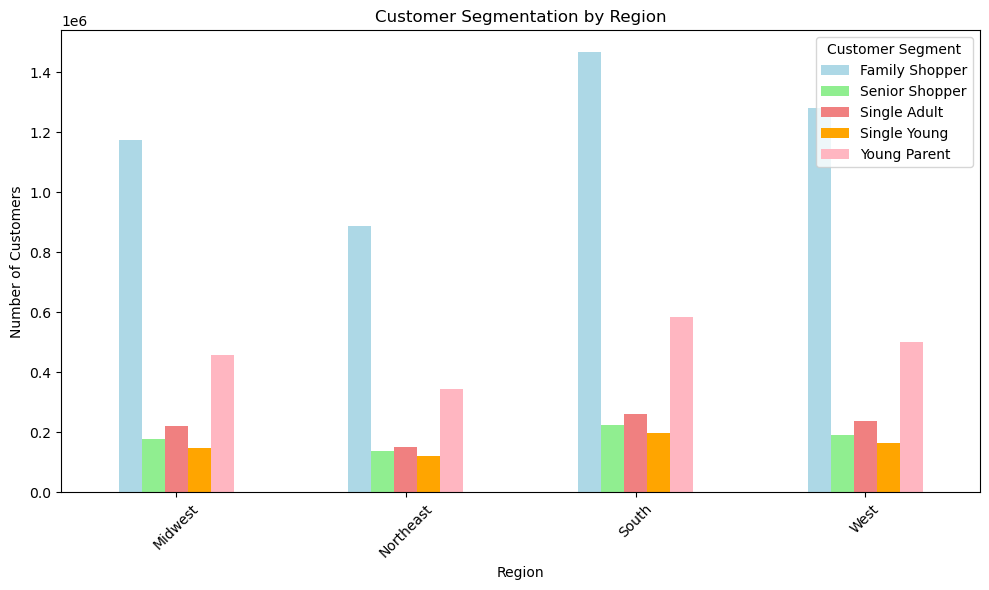

In [48]:
# Group by region and customer segment, and then unstack to pivot customer segments into columns
segment_by_region = sample_data.groupby(['region', 'customer_segment']).size().unstack().sort_index()

# Plot the stacked bar chart
segment_by_region_bar = segment_by_region.plot(kind='bar', stacked=False, figsize=(10,6), color=colors_segment)

# Set labels and title
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.title('Customer Segmentation by Region')

# Display the legend and adjust the x-axis labels
plt.legend(title='Customer Segment')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the chart
plt.show()

This stacked bar chart shows the distribution of customer segments across different regions. Here are some important points:
* Family Shoppers dominate the South and West regions, with significant contributions in the Midwest and Northeast as well.
* Single Adult and Young Parent segments are relatively small across all regions, with Single Young having more presence in the South and West.
* The Senior Shopper segment is most prominent in the South and the Midwest, but is present in smaller proportions across the other regions.
* Young Adults make up smaller portions in each region, with slightly higher numbers in the South compared to the other regions.
* The South is the region with higher amount of shoppers, while the Northeast region has a more even distribution.

/var/folders/bs/25x482152nx68y1wp8l2g42c0000gn/T/ipykernel_12198/1175820707.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_by_region = sample_data.groupby(['region', 'income_group']).size().unstack()


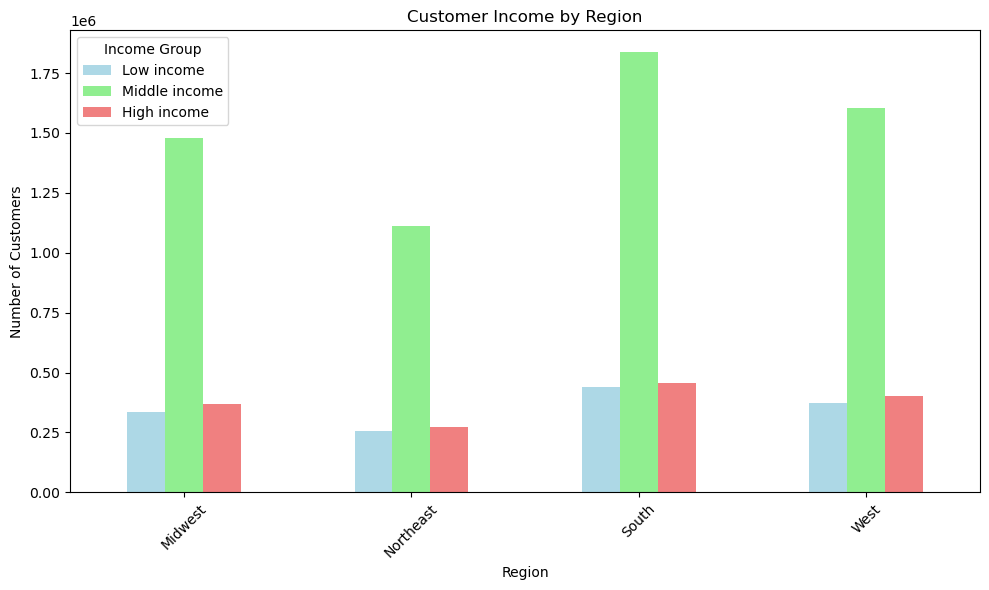

In [50]:
# Group by region and customer segment, and then unstack to pivot customer segments into columns
income_by_region = sample_data.groupby(['region', 'income_group']).size().unstack()

# Plot the stacked bar chart
income_by_region_bar = income_by_region.plot(kind='bar', stacked=False, figsize=(10,6), color=income_colors)

# Set labels and title
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.title('Customer Income by Region')

# Display the legend and adjust the x-axis labels
plt.legend(title='Income Group')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the chart
plt.show()

This bar chart illustrates the distribution of customer income groups across different regions. Here are some points:
* Middle income customers make up the largest proportion in every region, with a notable spike in the South and West regions.
* Low income customers are particularly prominent in the South, though they are also represented in all regions, but to a lesser extent compared to middle-income customers.
* High income customers have a smaller share overall, with a slight increase in the South and West regions.

In [52]:
# Region user count
sample_data.groupby('region')['user_id'].nunique()

region
Midwest      38354
Northeast    28561
South        47780
West         41455
Name: user_id, dtype: int64

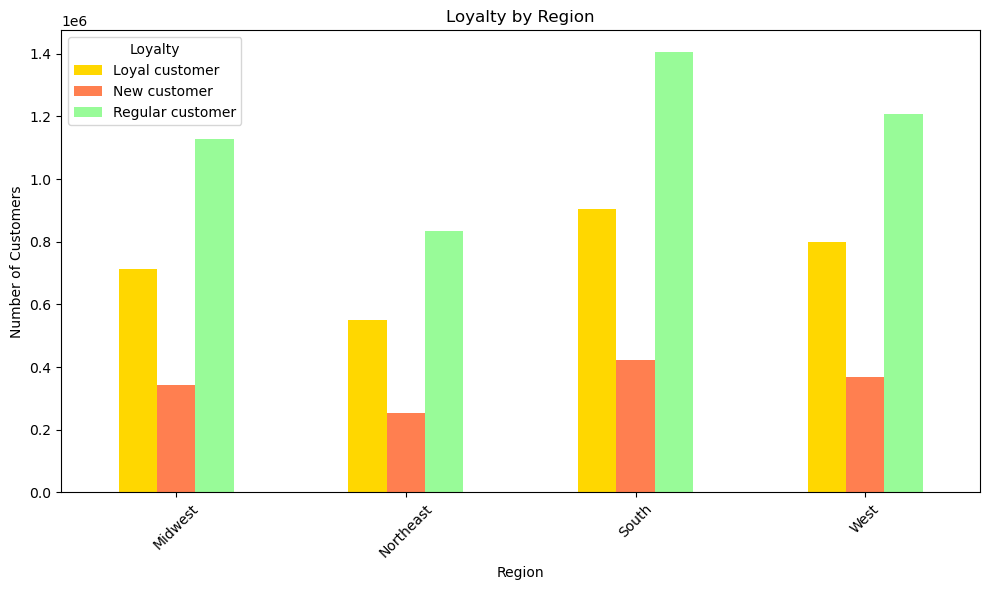

In [53]:
# Group by region and customer segment, and then unstack to pivot customer segments into columns
loyalty_by_region = sample_data.groupby(['region', 'loyalty_flag']).size().unstack()

colors_loyalty = ['#FFD700', '#FF7F50', '#98FB98']
# Plot the stacked bar chart
loyalty_by_region_bar = loyalty_by_region.plot(kind='bar', stacked=False, figsize=(10,6), color=colors_loyalty)

# Set labels and title
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.title('Loyalty by Region')

# Display the legend and adjust the x-axis labels
plt.legend(title='Loyalty')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the chart
plt.show()

### Time distribution

This section I am going to analyse the distribution of orders through the day and month. To clarify days of the week are labelled from 0 to 6 startin on Saturday = 0 till Friday = 6

In [56]:
# Create a temporary table
temp_df = sample_data.groupby(["orders_day_of_week", "order_hour_of_day"])["order_number"].aggregate("count").reset_index()

# Use pivot to reshape the data
temp_df = temp_df.pivot(index='orders_day_of_week', columns='order_hour_of_day', values='order_number')

# Display the result
temp_df.head()

order_hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
orders_day_of_week,,,,,,,,,,,,,,,,,,,,,
0,11153,6478,3548,2586,2341,3310,10341,38755,88330,127129,...,160278,157144,142658,111981,80561,61658,52506,44043,34682,20524
1,10595,5223,3063,2076,2250,4146,15436,48146,97148,146313,...,129800,126423,118706,96004,73579,56316,42718,34556,26251,16379
2,8593,4177,2383,2077,1966,3757,12746,35645,64481,95428,...,95675,94789,94626,78893,64653,48578,37313,29639,23003,15137
3,7820,3670,2431,1676,1957,3294,12007,32051,57013,80281,...,87585,89678,87541,74235,60892,46631,35102,29136,23497,14344
4,6949,3899,2217,1836,1934,3456,11682,32573,56133,77820,...,85370,85769,85261,72459,58875,48337,37654,31343,25650,15891


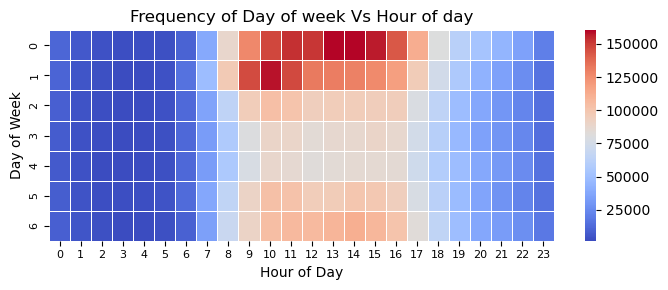

In [57]:
# Crate a heatmap
heatmap_time = plt.subplots(figsize=(7,3))
heatmap = sns.heatmap(temp_df, cmap="coolwarm", linewidths=.5)
heatmap.set_title("Frequency of Day of week Vs Hour of day", size = 12)
heatmap.set_xlabel("Hour of Day", size = 10)
heatmap.set_ylabel("Day of Week", size = 10)
heatmap.tick_params(axis = 'both', labelsize = 8)
cbar = heatmap.collections[0].colorbar
fig = heatmap.get_figure()
fig.savefig("Frequency of Day of week Vs Hour of day.png")
plt.tight_layout()
plt.show()

This heatmap displays the frequency of orders based on days of the week (y-axis) and hours of the day (x-axis). This are the key takeaways:
* The morning hours, especially from 9 AM to 12 PM, and early afternoon untill 16 PM are the peak times for orders across all days of the week.
* Obviously night time it's the slowest followed by late-night hours show little activity, indicating most orders happen during the daytime or early evening.
* Day 0 (Saturday) shows relatively higher activity in the mid-day hours compared to other days, which could indicate that customers shop more on Saturdays, possibly for planning meals for the upcoming week.
* During weekdays, the peak times align more with mid-morning and early afternoon, but the intensity of orders drops significantly towards the evening.

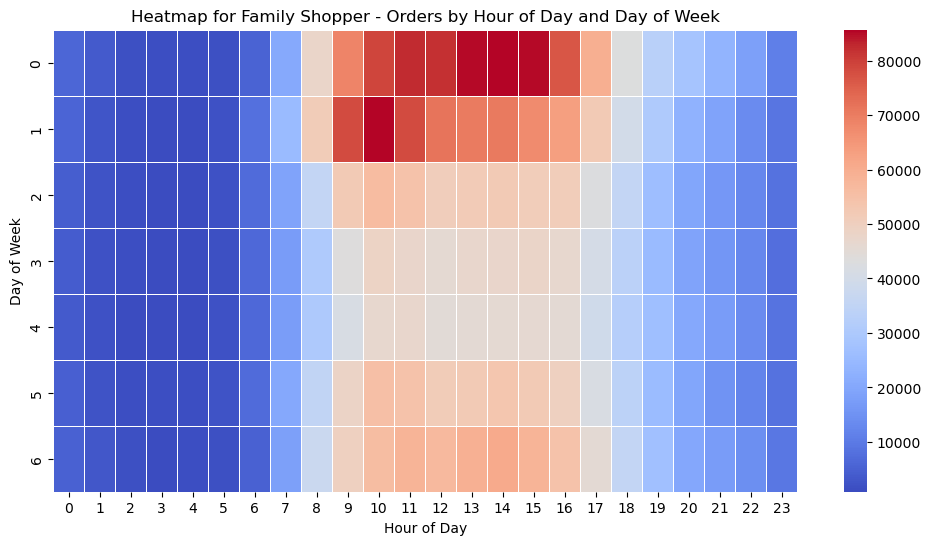

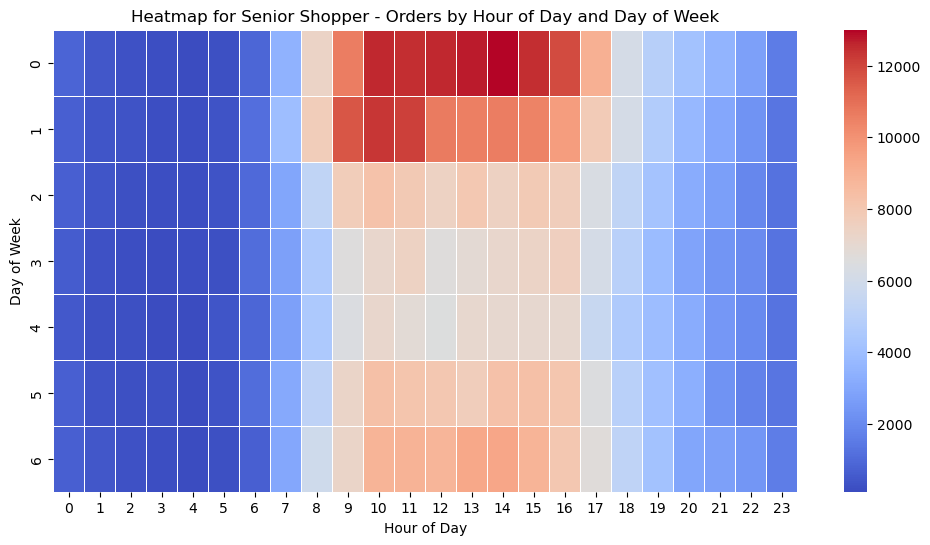

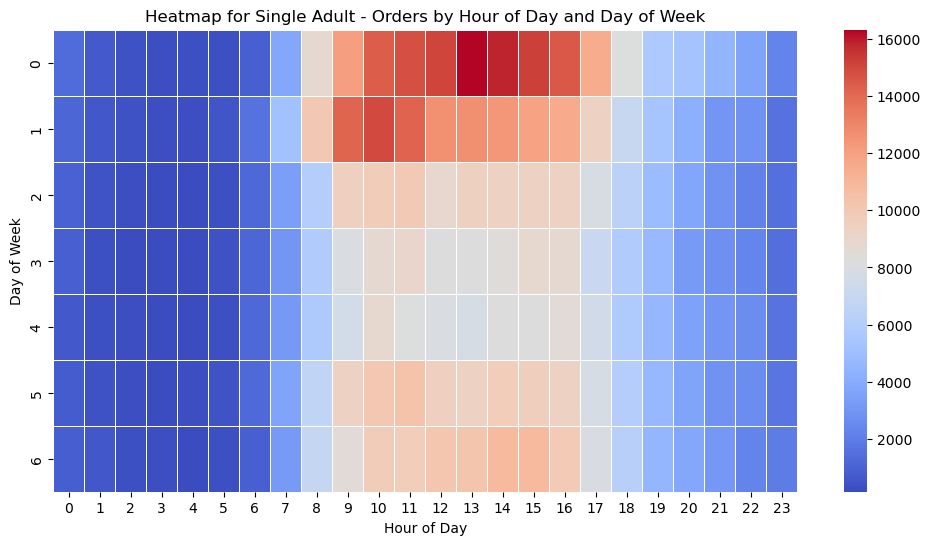

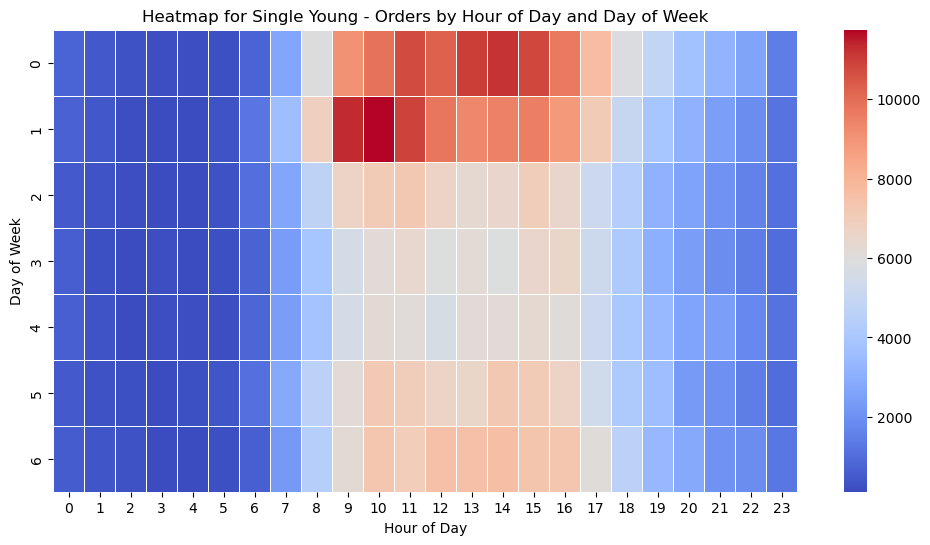

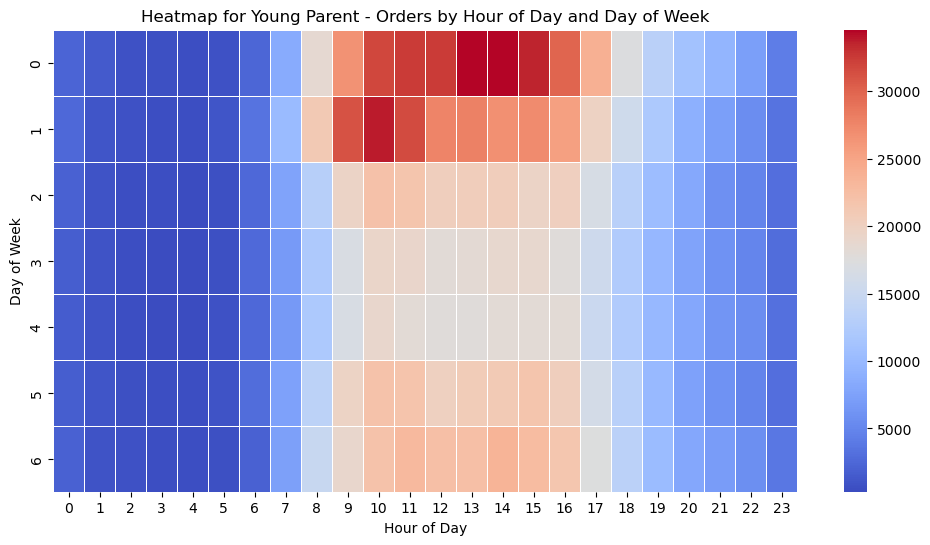

In [59]:
# Group by customer segment, day of week, and hour of day, and count the number of orders
heatmap_data = sample_data.groupby(['customer_segment', 'orders_day_of_week', 'order_hour_of_day'])['order_id'].count().reset_index()

# Loop through each unique customer segment 
for segment in heatmap_data['customer_segment'].unique():
    # Filter data for the current customer segment
    segment_data = heatmap_data[heatmap_data['customer_segment'] == segment]
    
    # Pivot the data for the heatmap (Day of Week as rows, Hour of Day as columns)
    segment_pivot = segment_data.pivot_table(index='orders_day_of_week', columns='order_hour_of_day', values='order_id', aggfunc='sum')
    
    # Plot the heatmap for the current segment
    plt.figure(figsize=(12, 6))
    sns.heatmap(segment_pivot, cmap='coolwarm', annot=False, fmt='d', linewidths=.5)
    
    # Set the title 
    plt.title(f'Heatmap for {segment} - Orders by Hour of Day and Day of Week')
    plt.xlabel('Hour of Day')
    plt.ylabel('Day of Week')

    # Save the heatmap as an image with the segment name
    heatmap_filename = os.path.join(path, '04 Analysis',  'Visualizations', f"{segment}_heatmap.png")
    plt.savefig(heatmap_filename)
    
    # Show the heatmap for this segment
    plt.show()

### Export visualizations

Export all visualizations from this notebook

In [62]:
profile_segmentation_bar.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'profile_segmentation_bar.png'))

bar_total_spending.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_total_spending.png'))

bar_total_orders.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_total_orders.png'))

customer_income_distribution.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'customer_income_distribution.png'))

product_bar.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'product_bar.png'))

product_customer_bar.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'product_customer_bar.png'))

segment_by_region_bar.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'segment_by_region_bar.png'))

income_by_region_bar.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'income_by_region_bar.png'))

loyalty_by_region_bar.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'loyalty_by_region_bar.png'))

heatmap.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'heatmap.png'))

### Export data

In [64]:
sample_data.to_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'sample_data_segmentation.pkl'))

### Export new visualisations

In [102]:
segment_boxplot.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'segment_boxplot.png'))

bar_avg_spending.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_avg_spending.png'))

bar_std_spending.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_std_spending.png'))

In [98]:
bar_avg_order.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_avg_orders.png'))